In [1]:
import urllib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
with urllib.request.urlopen(f"https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/edges/all_party_edges.csv") as response:
    df_party_edges = pd.read_csv(response)

df_party_edges.head()


,source,target,Period,total_votes_shared,total_votes_agreed,weight,topic
0,Danmarksdemokraterne,Danmarksdemokraterne,65,386,382.0,0.989637,finans_budget
1,Danmarksdemokraterne,Dansk Folkeparti,65,4643,4615.0,0.993969,finans_budget
2,Danmarksdemokraterne,Det Konservative Folkeparti,65,1887,1866.0,0.988871,finans_budget
3,Danmarksdemokraterne,Enhedslisten,65,70,30.0,0.428571,finans_budget
4,Danmarksdemokraterne,Inuit Ataqatigiit,65,21,2.0,0.095238,finans_budget


In [3]:
all_parties = list(set(list(list(df_party_edges['source'].unique()) + list(df_party_edges['target'].unique()))))
all_periods = df_party_edges['Period'].unique()
all_topics = df_party_edges['topic'].unique()
print(f"Data for {len(all_parties)} parties: {all_parties}")
print(f"Data for {len(all_periods)} periods: {all_periods}")
print(f"Data for {len(all_topics)} topics: {all_topics}")


Data for 27 parties: ['Kristeligt Folkeparti', 'Liberal Alliance', 'Javnaðarflokkurin', 'Moderaterne', 'Uden for folketingsgrupperne', 'Siumut', 'Sambandsflokkurin', 'Det Konservative Folkeparti', 'Radikale Venstre', 'Tjóðveldisflokkurin', 'Dansk Folkeparti', 'Ny Alliance', 'Kristendemokraterne', 'Socialistisk Folkeparti', 'Socialdemokratiet', 'Enhedslisten', 'Danmarksdemokraterne', 'Borgernes Parti', 'Venstre', 'Alternativet', 'Inuit Ataqatigiit', 'Tjóðveldi', 'Frie Grønne', 'Not able to assign', 'Naleraq', 'Nunatta Qitornai', 'Folkaflokkurin']
Data for 7 periods: [65 66 67 68 69 70 71]
Data for 15 topics: ['finans_budget' 'klima_miljø' 'erhverv' 'retspolitik' 'uddannelse' 'skat'
 'arbejdsmarked_velfærd' 'social_familie' 'forsvar_sikkerhed'
 'udenrigs_eu' 'transport_infrastruktur' 'sundhed' 'immigration' 'bolig'
 'General']


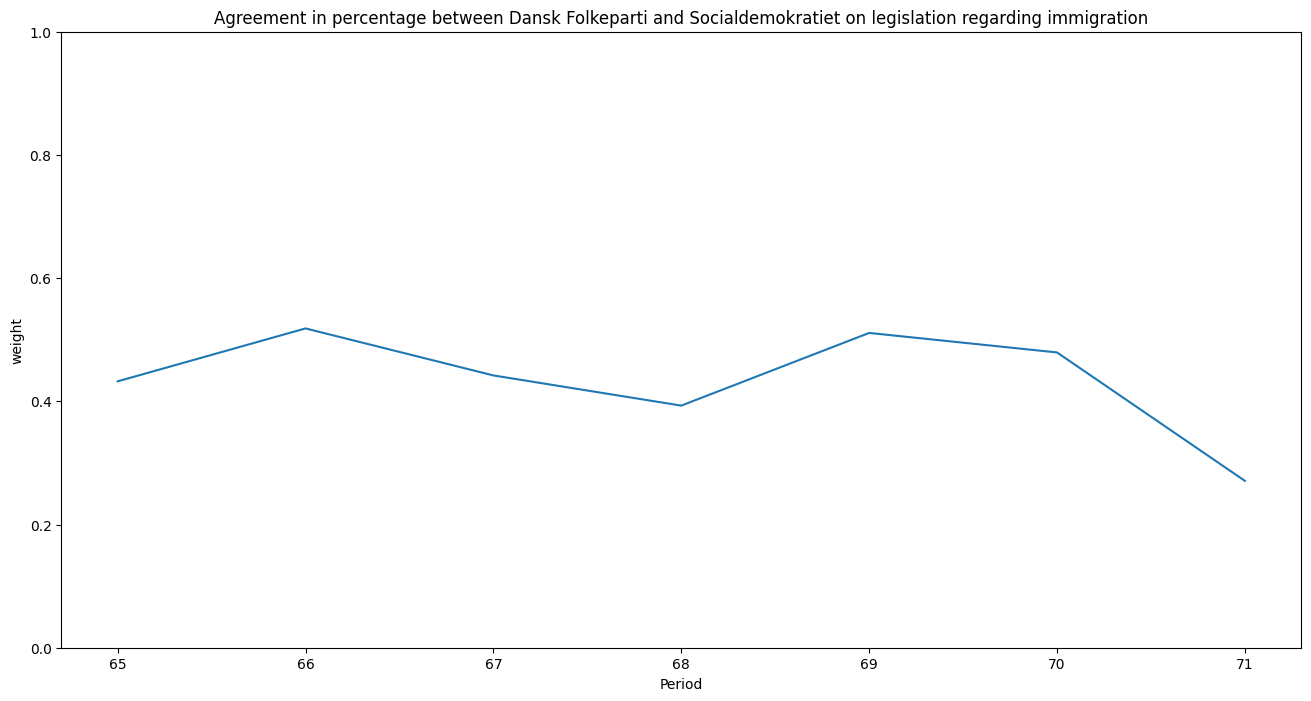

In [ ]:
unique_topics = df_party_edges["topic"].unique()
topic = "immigration"
party_1 = "Dansk Folkeparti"
party_2 = "Socialdemokratiet"

#Get the relevant rows
df_topic = df_party_edges[df_party_edges['topic'] == topic]

mask_1 = (df_topic['source'] == party_1) & (df_topic['target'] == party_2)
mask_2 = (df_topic['source'] == party_2) & (df_topic['target'] == party_1)
mask = mask_1 | mask_2
df_masked  = df_topic[mask_1]
# df_topic

figure, axs = plt.subplots(1,1,figsize = (16,8)) #Width, Height
plt.title(f"Agreement in percentage between {party_1} and {party_2} on legislation regarding {topic}")
sns.lineplot(data = df_masked, x = "Period", y = "weight", ax = axs)
axs.set_ylim(0,1)

plt.show()

In [35]:
df_topic_traditional

,source,target,Period,total_votes_shared,total_votes_agreed,weight,topic
19079,Det Konservative Folkeparti,Det Konservative Folkeparti,65,120,120.0,1.000000,immigration
19080,Det Konservative Folkeparti,Enhedslisten,65,23,23.0,1.000000,immigration
19083,Det Konservative Folkeparti,Liberal Alliance,65,30,30.0,1.000000,immigration
19087,Det Konservative Folkeparti,Radikale Venstre,65,99,99.0,1.000000,immigration
19088,Det Konservative Folkeparti,Socialdemokratiet,65,822,822.0,1.000000,immigration
...,...,...,...,...,...,...,...
20470,Venstre,Liberal Alliance,71,17146,14768.0,0.861309,immigration
20472,Venstre,Radikale Venstre,71,9379,7637.0,0.814266,immigration
20473,Venstre,Socialdemokratiet,71,53921,53496.0,0.992118,immigration
20474,Venstre,Socialistisk Folkeparti,71,14796,12002.0,0.811165,immigration


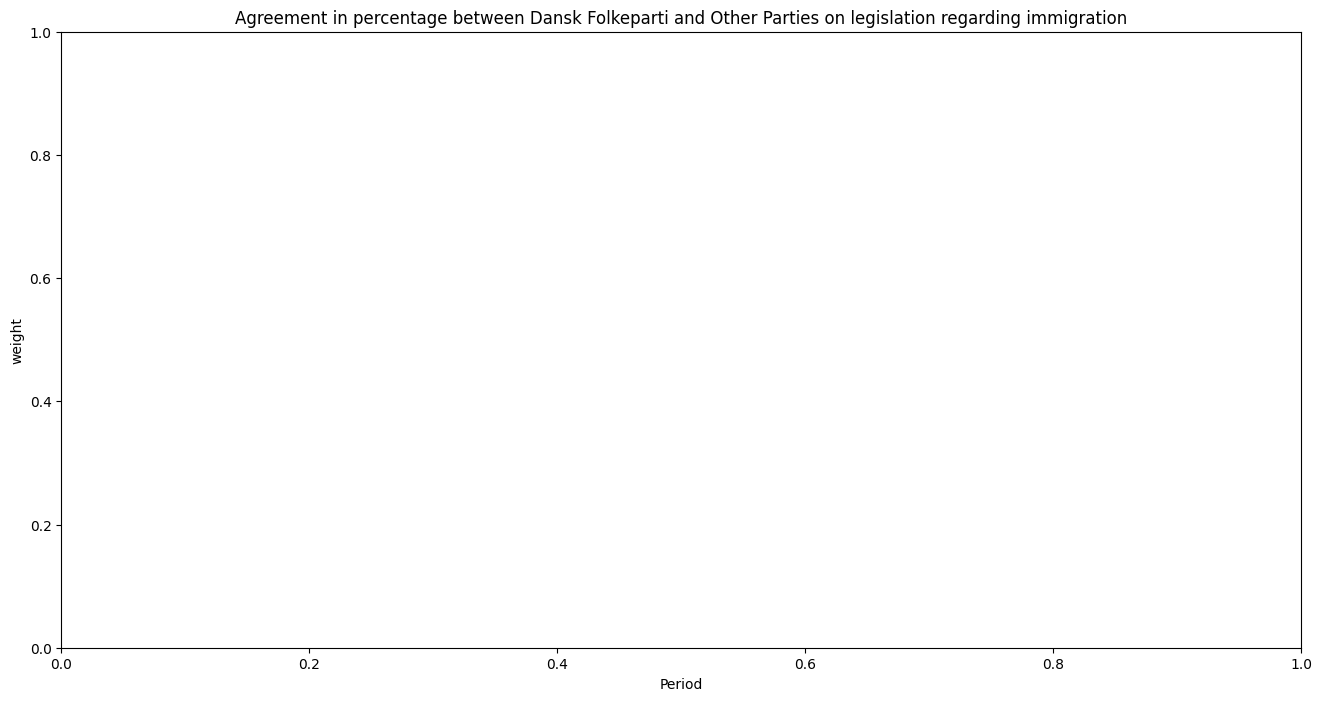

In [31]:
unique_topics = df_party_edges["topic"].unique()
topic = "immigration"
party_1 = "Dansk Folkeparti"

#Get the relevant rows
df_topic = df_party_edges[df_party_edges['topic'] == topic]


traditional_parties = ["Det Konservative Folkeparti", "Enhedslisten", "Liberal Alliance", "Radikale Venstre", "Socialdemokratiet", "Socialistisk Folkeparti", "Venstre"]
# parties_to_drop_momentarily = ['Kirsteligt Folkeparti', "Not able to assign", Ny Alliance]
mask_only_traditional_parties = (df_topic['source'].isin(traditional_parties)) & (df_topic['target'].isin(traditional_parties))
df_topic_traditional = df_topic[mask_only_traditional_parties]



mask_1 = (df_topic_traditional['source'] == party_1) & (df_topic_traditional['target'] != party_1)
# mask_2 = (df_topic['source'] == party_2) & (df_topic['target'] == party_1)
# mask = mask_1 | mask_2
df_masked  = df_topic_traditional[mask_1]
# df_topic

figure, axs = plt.subplots(1,1,figsize = (16,8)) #Width, Height
plt.title(f"Agreement in percentage between {party_1} and Other Parties on legislation regarding {topic}")
sns.lineplot(data = df_masked, x = "Period", y = "weight", hue = "target", ax = axs)
axs.set_ylim(0,1)

plt.show()
